Generating a synthetic dataset for student placement trends...
Dataset created successfully. Starting EDA...

--- Dataset Head ---
   Gender Specialization  College_Tier   GPA  Communication_Score  \
0    Male             CS             2  7.17                 93.0   
1  Female             CS             3  6.09                 72.0   
2    Male             CS             2  6.08                 67.0   
3    Male          Civil             2  8.91                 57.0   
4    Male           Mech             3  6.96                 85.0   

   Projects_Completed  Internships_Done  Years_Experience  Placed  
0                   3                 2                 1       0  
1                   3                 1                 2       1  
2                   4                 0                 0       0  
3                   3                 1                 1       0  
4                   5                 2                 2       0  

--- Dataset Info ---
<class 'pandas.core.fram

/tmp/ipykernel_2389/865933891.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Placed', data=df, palette='viridis')


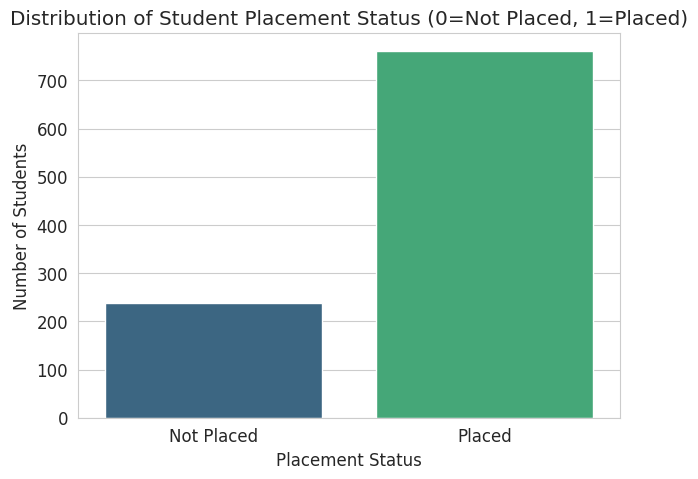

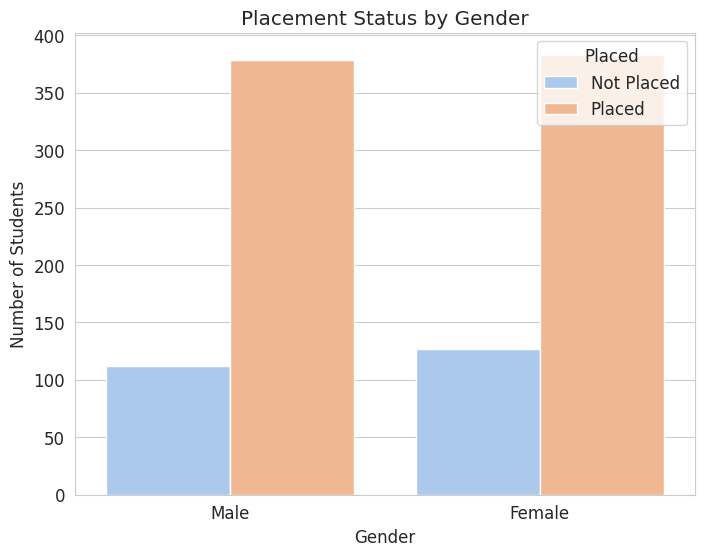

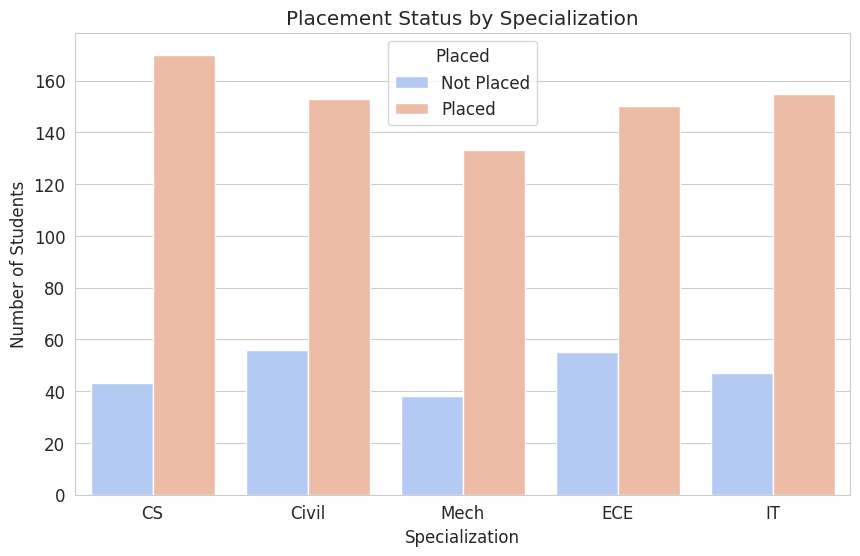

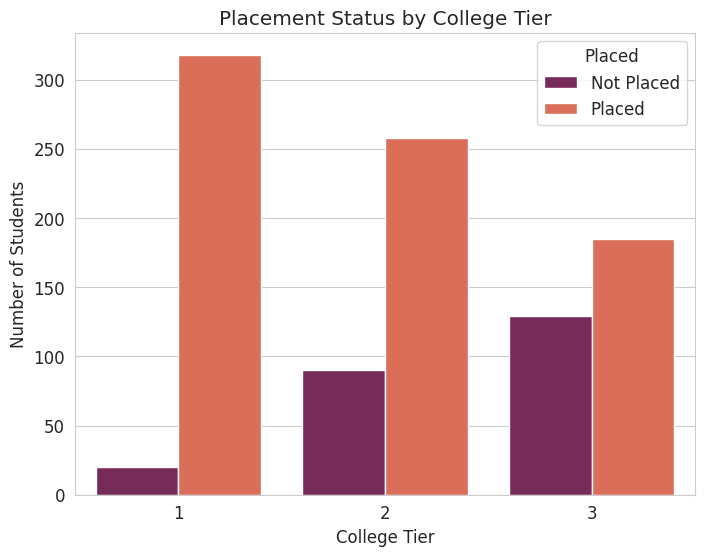

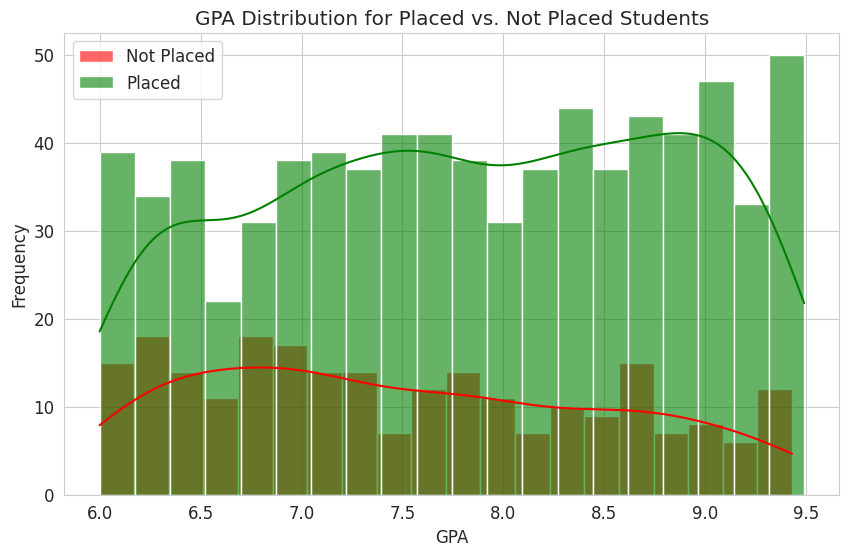

/tmp/ipykernel_2389/865933891.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Placed', y='GPA', data=df, palette='mako', ax=axes[0])
/tmp/ipykernel_2389/865933891.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Placed', y='Communication_Score', data=df, palette='mako', ax=axes[1])


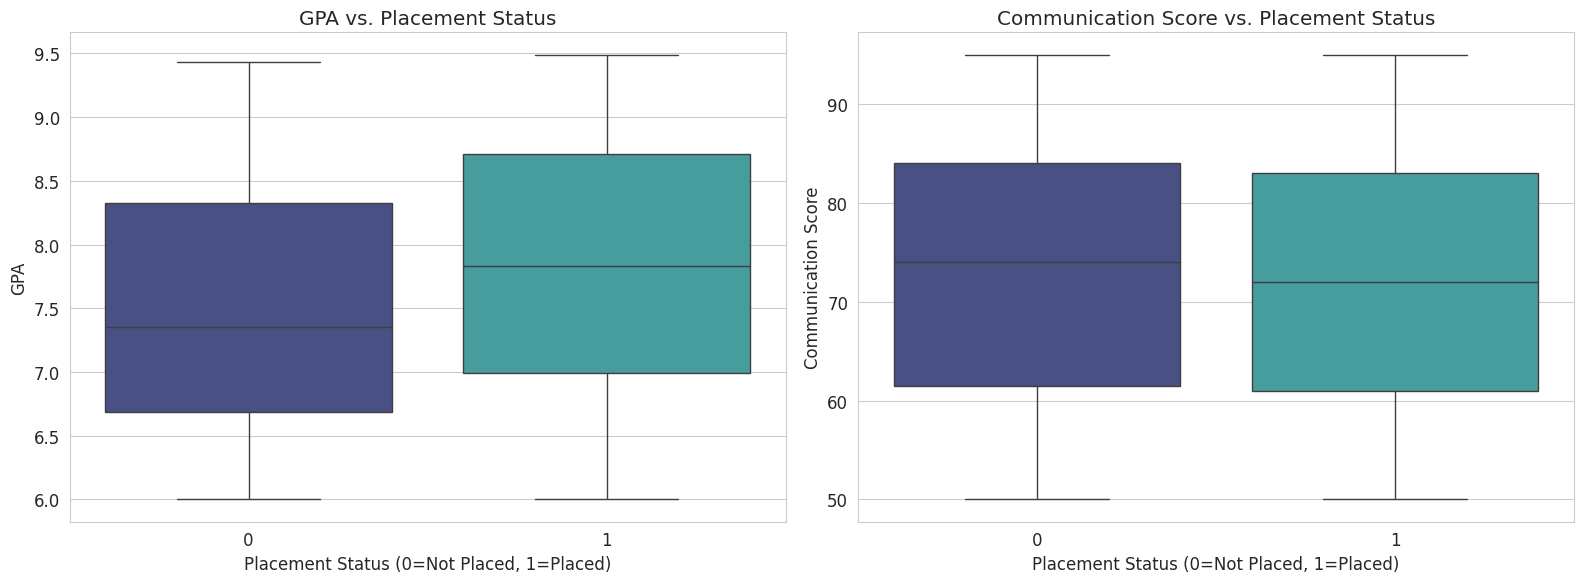

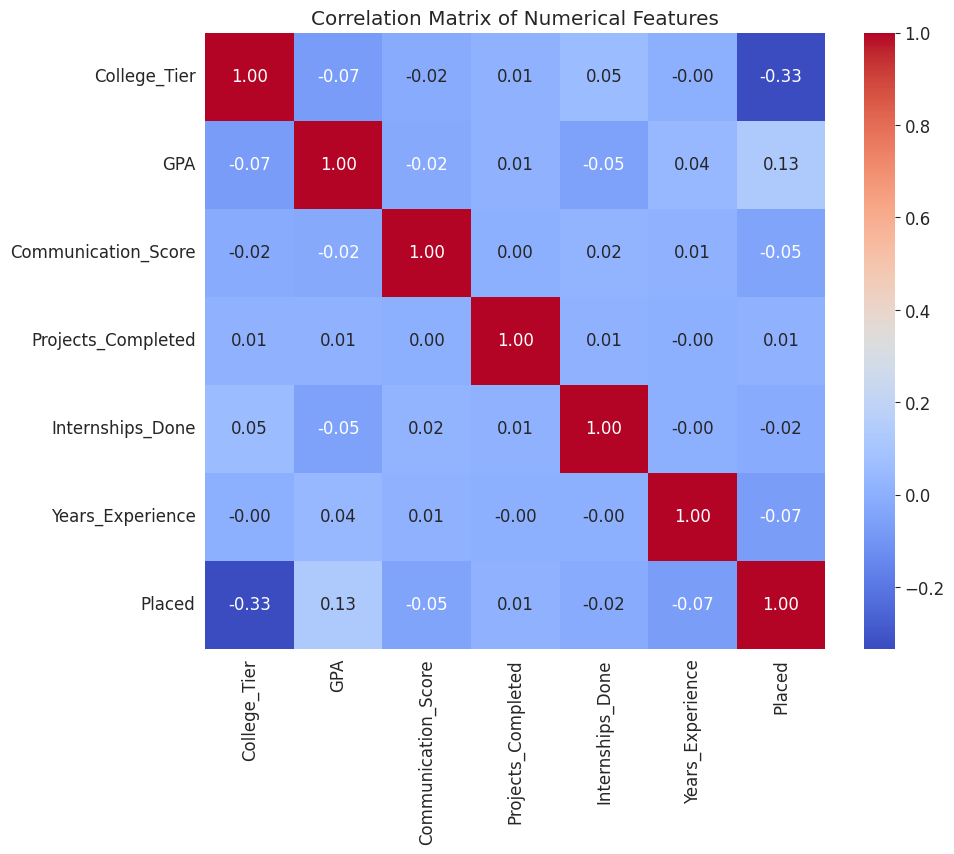

EDA complete. Explore the generated plots and insights!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Generating a synthetic dataset for student placement trends...")

# Create a synthetic dataset for student placement trends
np.random.seed(42)
num_students = 1000
data = {
    'Gender': np.random.choice(['Male', 'Female'], num_students),
    'Specialization': np.random.choice(['CS', 'IT', 'ECE', 'Mech', 'Civil'], num_students),
    'College_Tier': np.random.choice([1, 2, 3], num_students),
    'GPA': np.random.uniform(6.0, 9.5, num_students).round(2),
    'Communication_Score': np.random.uniform(50, 95, num_students).round(0),
    'Projects_Completed': np.random.randint(0, 6, num_students),
    'Internships_Done': np.random.randint(0, 3, num_students),
    'Years_Experience': np.random.randint(0, 3, num_students),
    'Placed': np.random.choice([0, 1], num_students, p=[0.3, 0.7]) # 70% placed
}
df = pd.DataFrame(data)

# Introduce some correlation and noise for 'Placed' status
df.loc[df['GPA'] > 8.0, 'Placed'] = np.random.choice([0, 1], sum(df['GPA'] > 8.0), p=[0.1, 0.9])
df.loc[df['GPA'] < 7.0, 'Placed'] = np.random.choice([0, 1], sum(df['GPA'] < 7.0), p=[0.6, 0.4])
df.loc[df['College_Tier'] == 1, 'Placed'] = np.random.choice([0, 1], sum(df['College_Tier'] == 1), p=[0.05, 0.95])
df.loc[df['College_Tier'] == 3, 'Placed'] = np.random.choice([0, 1], sum(df['College_Tier'] == 3), p=[0.4, 0.6])

print("Dataset created successfully. Starting EDA...")

# 1. Display basic information about the dataset
print("\n--- Dataset Head ---")
print(df.head())

print("\n--- Dataset Info ---")
df.info()

print("\n--- Dataset Description ---")
print(df.describe())

# 2. Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 3. Distribution of 'Placed' status
plt.figure(figsize=(7, 5))
sns.countplot(x='Placed', data=df, palette='viridis')
plt.title('Distribution of Student Placement Status (0=Not Placed, 1=Placed)')
plt.xlabel('Placement Status')
plt.ylabel('Number of Students')
plt.xticks([0, 1], ['Not Placed', 'Placed'])
plt.show()

# 4. Placement trends by Gender
plt.figure(figsize=(8, 6))
sns.countplot(x='Gender', hue='Placed', data=df, palette='pastel')
plt.title('Placement Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Students')
plt.legend(title='Placed', labels=['Not Placed', 'Placed'])
plt.show()

# 5. Placement trends by Specialization
plt.figure(figsize=(10, 6))
sns.countplot(x='Specialization', hue='Placed', data=df, palette='coolwarm')
plt.title('Placement Status by Specialization')
plt.xlabel('Specialization')
plt.ylabel('Number of Students')
plt.legend(title='Placed', labels=['Not Placed', 'Placed'])
plt.show()

# 6. Placement trends by College Tier
plt.figure(figsize=(8, 6))
sns.countplot(x='College_Tier', hue='Placed', data=df, palette='rocket')
plt.title('Placement Status by College Tier')
plt.xlabel('College Tier')
plt.ylabel('Number of Students')
plt.legend(title='Placed', labels=['Not Placed', 'Placed'])
plt.show()

# 7. Distribution of GPA for Placed vs Not Placed students
plt.figure(figsize=(10, 6))
sns.histplot(df[df['Placed'] == 0]['GPA'], color='red', label='Not Placed', kde=True, alpha=0.6, bins=20)
sns.histplot(df[df['Placed'] == 1]['GPA'], color='green', label='Placed', kde=True, alpha=0.6, bins=20)
plt.title('GPA Distribution for Placed vs. Not Placed Students')
plt.xlabel('GPA')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# 8. Box plot for GPA and Communication Score by Placement Status
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(x='Placed', y='GPA', data=df, palette='mako', ax=axes[0])
axes[0].set_title('GPA vs. Placement Status')
axes[0].set_xlabel('Placement Status (0=Not Placed, 1=Placed)')
axes[0].set_ylabel('GPA')

sns.boxplot(x='Placed', y='Communication_Score', data=df, palette='mako', ax=axes[1])
axes[1].set_title('Communication Score vs. Placement Status')
axes[1].set_xlabel('Placement Status (0=Not Placed, 1=Placed)')
axes[1].set_ylabel('Communication Score')
plt.tight_layout()
plt.show()

# 9. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print("EDA complete. Explore the generated plots and insights!")